In [15]:
import sys
import random
import time
from pathlib import Path

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
from sklearn import __version__ as sklearn_version
from skeLCS import eLCS

print("Scikit-learn version:", sklearn_version)
print("eLCS imported successfully.")

Scikit-learn version: 1.9.0
eLCS imported successfully.


In [18]:
DATA_PATH = Path("f1_raw_merged_master.csv")

df = pd.read_csv(
    DATA_PATH,
    na_values="\\N",
    low_memory=False
)

df_original = df.copy(deep=True)

print("Raw dataset shape:", df_original.shape)
df_original.head()

Raw dataset shape: (26759, 72)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,driverStandingsId,points_driver_standing,position_driver_standing,positionText_driver_standing,wins,constructorStandingsId,points_team_standing,position_team_standing,positionText_team_standing,wins_team_standing
0,1,18,1,1,22.0,1,1.0,1,1,10.0,...,1.0,10.0,1.0,1,1.0,1.0,14.0,1.0,1,1.0
1,2,18,2,2,3.0,5,2.0,2,2,8.0,...,2.0,8.0,2.0,2,0.0,2.0,8.0,3.0,3,0.0
2,3,18,3,3,7.0,7,3.0,3,3,6.0,...,3.0,6.0,3.0,3,0.0,3.0,9.0,2.0,2,0.0
3,4,18,4,4,5.0,11,4.0,4,4,5.0,...,4.0,5.0,4.0,4,0.0,4.0,5.0,4.0,4,0.0
4,5,18,5,1,23.0,3,5.0,5,5,4.0,...,5.0,4.0,5.0,5,0.0,1.0,14.0,1.0,1,1.0


In [19]:
print("Rows:", len(df_original))
print("Columns:", len(df_original.columns))
print("Races:", df_original["raceId"].nunique())
print("Drivers:", df_original["driverId"].nunique())
print("Constructors:", df_original["constructorId"].nunique())
print("Years:", df_original["year"].min(), "to", df_original["year"].max())
print("Duplicate rows:", df_original.duplicated().sum())
print(
    "Duplicate result IDs:",
    df_original["resultId"].duplicated().sum()
)

Rows: 26759
Columns: 72
Races: 1125
Drivers: 861
Constructors: 211
Years: 1950 to 2024
Duplicate rows: 0
Duplicate result IDs: 0


In [20]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [21]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score

X_example, y_example = make_classification(
    n_samples=300,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    n_classes=2,
    random_state=RANDOM_STATE
)

X_example_train, X_example_test, y_example_train, y_example_test = (
    train_test_split(
        X_example,
        y_example,
        test_size=0.20,
        stratify=y_example,
        random_state=RANDOM_STATE
    )
)

compatibility_model = eLCS(
    learning_iterations=1000,
    N=500,
    random_state=RANDOM_STATE
)

compatibility_model.fit(
    X_example_train,
    y_example_train
)

compatibility_predictions = compatibility_model.predict(
    X_example_test
)

compatibility_score = balanced_accuracy_score(
    y_example_test,
    compatibility_predictions
)

print("eLCS test completed.")
print("Balanced accuracy:", round(compatibility_score, 4))
print(
    "Final number of rules:",
    len(compatibility_model.population.popSet)
)

eLCS test completed.
Balanced accuracy: 0.75
Final number of rules: 104


In [22]:
# Tools used to replace missing values and evaluate classification performance
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [23]:
# Keep the original imported data unchanged by working on a separate copy
raw_model_df = df_original.copy()

# Create the binary target:
# 1 means the driver finished in the top three and 0 means they did not
raw_model_df["podium"] = (
    raw_model_df["positionOrder"]
    .between(1, 3)
    .astype(int)
)

# Convert race dates into a format that can be sorted chronologically
raw_model_df["race_date"] = pd.to_datetime(
    raw_model_df["date"],
    errors="coerce"
)

# Create one record per race and arrange the races from earliest to latest
race_order = (
    raw_model_df[["raceId", "race_date"]]
    .drop_duplicates()
    .sort_values(["race_date", "raceId"])
    .reset_index(drop=True)
)

# Use the earliest 80% of races for training
# and the most recent 20% for testing
race_cutoff = int(len(race_order) * 0.80)

training_race_ids = set(
    race_order.iloc[:race_cutoff]["raceId"]
)

testing_race_ids = set(
    race_order.iloc[race_cutoff:]["raceId"]
)

# Keep every driver from the same race in the same dataset partition
train_mask = raw_model_df["raceId"].isin(
    training_race_ids
)

test_mask = raw_model_df["raceId"].isin(
    testing_race_ids
)

# Display the split details so the experiment can be checked and reproduced
print("Training races:", len(training_race_ids))
print("Testing races:", len(testing_race_ids))
print("Training rows:", train_mask.sum())
print("Testing rows:", test_mask.sum())

print(
    "Training period:",
    raw_model_df.loc[
        train_mask,
        "race_date"
    ].min().date(),
    "to",
    raw_model_df.loc[
        train_mask,
        "race_date"
    ].max().date()
)

print(
    "Testing period:",
    raw_model_df.loc[
        test_mask,
        "race_date"
    ].min().date(),
    "to",
    raw_model_df.loc[
        test_mask,
        "race_date"
    ].max().date()
)

Training races: 900
Testing races: 225
Training rows: 22199
Testing rows: 4560
Training period: 1950-05-13 to 2014-04-06
Testing period: 2014-04-20 to 2024-12-08


In [24]:
# Use numerical information that was available before the race began
# without adding individually engineered features
raw_feature_names = [
    "grid",
    "year",
    "round",
    "lat",
    "lng",
    "alt",
    "position_quali"
]

# Create separate feature tables for the chronological training and test sets
X_raw_train_df = raw_model_df.loc[
    train_mask,
    raw_feature_names
].copy()

X_raw_test_df = raw_model_df.loc[
    test_mask,
    raw_feature_names
].copy()

# Store the corresponding podium target values as integer arrays
y_raw_train = raw_model_df.loc[
    train_mask,
    "podium"
].to_numpy(dtype=int)

y_raw_test = raw_model_df.loc[
    test_mask,
    "podium"
].to_numpy(dtype=int)

# Check the selected features and the class imbalance in each partition
print("Raw baseline features:", raw_feature_names)
print(
    "Training class counts:",
    np.bincount(y_raw_train)
)
print(
    "Testing class counts:",
    np.bincount(y_raw_test)
)

Raw baseline features: ['grid', 'year', 'round', 'lat', 'lng', 'alt', 'position_quali']
Training class counts: [19477  2722]
Testing class counts: [3885  675]


In [25]:
# Learn a median replacement value for each feature from training data only
# so information from the test period cannot enter preprocessing
raw_imputer = SimpleImputer(
    strategy="median"
)

X_raw_train = raw_imputer.fit_transform(
    X_raw_train_df
)

# Apply the training medians to the unseen test data
X_raw_test = raw_imputer.transform(
    X_raw_test_df
)

# Confirm that eLCS will receive complete numerical arrays
assert not np.isnan(X_raw_train).any()
assert not np.isnan(X_raw_test).any()

print("Training feature shape:", X_raw_train.shape)
print("Testing feature shape:", X_raw_test.shape)

Training feature shape: (22199, 7)
Testing feature shape: (4560, 7)


In [26]:
def get_positive_probability(model, X):
    """Return the model's probability score for the podium class."""

    probabilities = model.predict_proba(X)

    # Binary classification should return one column for each class
    if (
        probabilities.ndim != 2
        or probabilities.shape[1] < 2
    ):
        raise ValueError(
            "Two-class probabilities were not returned."
        )

    # The second column represents the positive podium class
    return probabilities[:, 1]


def evaluate_binary_classifier(
    model_name,
    y_true,
    y_pred,
    y_probability,
    training_seconds
):
    """Calculate the metrics used to compare every Phase II model."""

    return {
        "model": model_name,

        # Overall proportion of correct predictions
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        # Proportion of predicted podiums that were actually podiums
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        # Proportion of actual podiums successfully identified
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        # Combined measure of podium precision and recall
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        # Average performance across the podium and non-podium classes
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),

        # Measures class-ranking performance across decision thresholds
        "roc_auc": roc_auc_score(
            y_true,
            y_probability
        ),

        # Focuses on positive-class performance in this imbalanced dataset
        "pr_auc": average_precision_score(
            y_true,
            y_probability
        ),

        # Records computational cost for later model comparison
        "training_seconds": training_seconds
    }

In [27]:
# Record the complete original configuration so the raw baseline
# can be reproduced and compared fairly with the improved eLCS
original_elcs_parameters = {
    "learning_iterations": 10000,
    "track_accuracy_while_fit": False,
    "N": 1000,
    "p_spec": 0.5,
    "discrete_attribute_limit": 10,
    "nu": 5,
    "chi": 0.8,
    "mu": 0.04,
    "theta_GA": 25,
    "theta_del": 20,
    "theta_sub": 20,
    "acc_sub": 0.99,
    "beta": 0.2,
    "delta": 0.1,
    "init_fit": 0.01,
    "fitness_reduction": 0.1,
    "do_correct_set_subsumption": False,
    "do_GA_subsumption": True,
    "selection_method": "tournament",
    "theta_sel": 0.5,
    "match_for_missingness": False,
    "random_state": RANDOM_STATE
}

# Display the settings used by the unoptimised model
pd.Series(
    original_elcs_parameters,
    name="Baseline value"
)

learning_iterations                10000
track_accuracy_while_fit           False
N                                   1000
p_spec                               0.5
discrete_attribute_limit              10
nu                                     5
chi                                  0.8
mu                                  0.04
theta_GA                              25
theta_del                             20
theta_sub                             20
acc_sub                             0.99
beta                                 0.2
delta                                0.1
init_fit                            0.01
fitness_reduction                    0.1
do_correct_set_subsumption         False
do_GA_subsumption                   True
selection_method              tournament
theta_sel                            0.5
match_for_missingness              False
random_state                          42
Name: Baseline value, dtype: object

In [28]:
# Construct the original eLCS without any parameter optimisation
raw_elcs_model = eLCS(
    **original_elcs_parameters
)

# Measure the time required to train the baseline model
raw_start_time = time.perf_counter()

raw_elcs_model.fit(
    X_raw_train,
    y_raw_train
)

raw_training_seconds = (
    time.perf_counter()
    - raw_start_time
)

# Predict the podium class for the later unseen races
raw_elcs_predictions = (
    raw_elcs_model
    .predict(X_raw_test)
    .astype(int)
)

# Obtain podium probability scores for ROC-AUC and PR-AUC
raw_elcs_probabilities = (
    get_positive_probability(
        raw_elcs_model,
        X_raw_test
    )
)

# Store the baseline results in a reusable dictionary
raw_elcs_results = (
    evaluate_binary_classifier(
        model_name="Original eLCS - raw data",
        y_true=y_raw_test,
        y_pred=raw_elcs_predictions,
        y_probability=raw_elcs_probabilities,
        training_seconds=raw_training_seconds
    )
)

pd.Series(raw_elcs_results)

model                Original eLCS - raw data
accuracy                             0.851974
precision                                 0.0
recall                                    0.0
f1                                        0.0
balanced_accuracy                         0.5
roc_auc                              0.887842
pr_auc                               0.646214
training_seconds                    28.556022
dtype: object

In [29]:
# Display class-specific precision, recall and F1 results
print(
    classification_report(
        y_raw_test,
        raw_elcs_predictions,
        target_names=[
            "Non-podium",
            "Podium"
        ],
        zero_division=0
    )
)

# Count correct and incorrect predictions for both target classes
raw_confusion_matrix = confusion_matrix(
    y_raw_test,
    raw_elcs_predictions
)

print(
    "Confusion matrix:\n",
    raw_confusion_matrix
)

# Record properties of the final learned rule population
print(
    "Macroclassifiers:",
    len(raw_elcs_model.population.popSet)
)

print(
    "Microclassifiers:",
    raw_elcs_model.population.microPopSize
)

# Report how much of the training data was covered by learned rules
print(
    "Training instance coverage:",
    round(
        raw_elcs_model
        .get_final_instance_coverage(),
        4
    )
)

print(
    "Training time:",
    round(raw_training_seconds, 2),
    "seconds"
)

              precision    recall  f1-score   support

  Non-podium       0.85      1.00      0.92      3885
      Podium       0.00      0.00      0.00       675

    accuracy                           0.85      4560
   macro avg       0.43      0.50      0.46      4560
weighted avg       0.73      0.85      0.78      4560

Confusion matrix:
 [[3885    0]
 [ 675    0]]
Macroclassifiers: 735
Microclassifiers: 1000
Training instance coverage: 1.0
Training time: 28.56 seconds


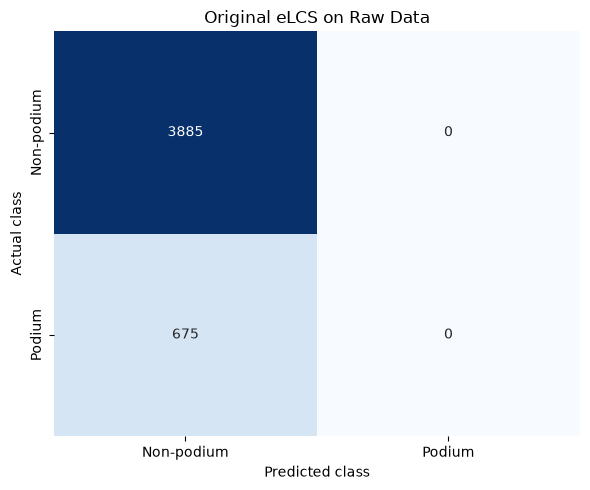

In [30]:
# Visualise the four possible classification outcomes
plt.figure(figsize=(6, 5))

sns.heatmap(
    raw_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Non-podium",
        "Podium"
    ],
    yticklabels=[
        "Non-podium",
        "Podium"
    ]
)

plt.title("Original eLCS on Raw Data")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()
plt.show()